# 3DFF-Net IPH + PHE 2.5D Segmentation - refined pseudo hemorrhage

This notebook is based on `02_3dff_net_iph_phe_25d_segmentation.ipynb`, but fixes the QC issue found in the pseudo hemorrhage labels.

Main change:
- The old pseudo IPH rule used a broad HU mask inside a wide PHE dilation ROI.
- The new rule uses high-confidence HU seeds, grows only inside a tighter PHE-adjacent ROI, limits candidates to the PHE slice/bounding-box neighborhood, filters components by volume/contact/mean HU, and keeps fewer components.

Expected effect: fewer false-positive pseudo hemorrhage regions while preserving compact blood-like regions adjacent to the manual PHE mask.

Labels:
- `0`: background
- `1`: refined pseudo IPH / hematoma
- `2`: manual PHE / perihematomal edema


## 0. Dependency notes


In [2]:
INSTALL_BASIC_DEPS = False

if INSTALL_BASIC_DEPS:
    import sys
    import subprocess
    pkgs = ["numpy", "pandas", "matplotlib", "scipy", "nibabel", "tqdm", "torch", "torchvision"]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *pkgs])


## 1. Configuration


In [3]:
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Optional, Sequence, Tuple


@dataclass
class ThreeDFFConfig:
    project_root: Path = Path.cwd()
    seed: int = 42

    # Run switches.
    run_training: bool = True
    run_final_eval: bool = True
    debug_small_run: bool = False
    debug_train_cases: int = 8
    debug_val_cases: int = 4
    debug_test_cases: int = 4
    debug_epochs: int = 2

    # 2.5D input: D neighboring slices, each represented by 3 CT windows.
    image_size: int = 512
    slice_offsets: tuple = (-2, -1, 0, 1, 2)
    ct_windows: tuple = (
        (-20.0, 100.0),   # brain / edema window
        (-50.0, 150.0),   # blood-sensitive window
        (0.0, 600.0),     # wide tissue/bone context
    )

    # Optional real IPH masks. Keep None when only PHE masks are available.
    true_iph_mask_dir: Optional[str] = None

    # Refined pseudo IPH generation.
    # Old broad HU rule created too many false positives. The new rule uses
    # high-confidence seeds and only grows compact components near the PHE border.
    pseudo_seed_hu_low: float = 55.0
    pseudo_seed_hu_high: float = 95.0
    pseudo_grow_hu_low: float = 42.0
    pseudo_grow_hu_high: float = 100.0
    pseudo_seed_roi_mm: float = 6.0
    pseudo_grow_roi_mm: float = 12.0
    pseudo_contact_mm: float = 4.0
    pseudo_bbox_margin_mm: float = 28.0
    pseudo_z_margin_slices: int = 2
    pseudo_min_component_ml: float = 0.05
    pseudo_max_component_ml: float = 80.0
    pseudo_max_components: int = 2
    pseudo_min_seed_voxels: int = 4
    pseudo_min_mean_hu: float = 45.0
    pseudo_max_long_axis_mm: float = 75.0
    pseudo_min_extent_large_component: float = 0.015
    pseudo_remove_phe_overlap: bool = True
    pseudo_fill_holes: bool = True

    # Architecture.
    backbone: str = "resnet18"
    pretrained_backbone: bool = True
    fpn_channels: int = 128
    decoder_channels: tuple = (128, 96, 64, 48)
    num_classes: int = 3

    # Training.
    epochs: int = 100
    batch_size: int = 2
    grad_accum_steps: int = 2
    lr_backbone: float = 1e-5
    lr_head: float = 5e-5
    weight_decay: float = 1e-4
    patience: int = 20
    min_delta: float = 1e-4
    freeze_backbone_epochs: int = 2
    amp: bool = True
    num_workers: int = 0
    augment_train: bool = True
    positive_slice_weight: float = 3.0
    lambda_ce: float = 1.0
    lambda_dice: float = 1.0
    lambda_boundary: float = 0.02
    class_weight_min: float = 0.05
    class_weight_max: float = 8.0
    background_weight_cap: float = 0.30

    # Inference/calibration.
    foreground_threshold: float = 0.50
    tune_threshold_on_val: bool = True
    threshold_grid: tuple = (
        0.30, 0.35, 0.40, 0.45, 0.50,
        0.55, 0.60, 0.65, 0.70, 0.75,
        0.80, 0.85, 0.90, 0.95,
    )
    use_tta_flip: bool = True
    use_postprocess: bool = True
    min_component_ml_iph: float = 0.05
    min_component_ml_phe: float = 0.15
    max_components_iph: int = 2
    max_components_phe: int = 3
    nsd_tolerance_mm: float = 1.0
    save_probability_npz: bool = True
CFG = ThreeDFFConfig()

# =========================
# Kaggle input paths
# =========================
PROJECT_ROOT = Path("/kaggle/working").resolve()

SEG_CQ500_ROOT = Path("/kaggle/input/datasets/onanhv/seg-cq500/Seg-CQ500").resolve()
PHE_DATASET_ROOT = Path("/kaggle/input/datasets/onanhv/phe-sich-ct-ids/PHE-SICH-CT-IDS").resolve()
INSTANCE2022_ROOT = Path("/kaggle/input/datasets/onanhv/instance2022/Instance2022").resolve()

# =========================
# PHE-SICH-CT-IDS paths
# =========================
PHE_ROOT = PHE_DATASET_ROOT / "SubdatasetA_NIFIT" / "NIFIT"
PHE_IMAGE_DIR = PHE_ROOT / "set"
PHE_MASK_DIR = PHE_ROOT / "label"

# =========================
# Optional external datasets
# =========================
# Seg-CQ500: dùng nếu code phía sau cần ICH/hemorrhage mask hoặc CT phụ trợ
SEG_CQ500_IMAGE_DIR = SEG_CQ500_ROOT
SEG_CQ500_MASK_DIR = SEG_CQ500_ROOT
00
# Instance2022: dùng nếu code phía sau cần detection / segmentation annotation phụ trợ
INSTANCE2022_IMAGE_DIR = INSTANCE2022_ROOT
INSTANCE2022_MASK_DIR = INSTANCE2022_ROOT

# Nếu có real IPH mask thì gán path tại đây.
# Hiện tại chưa chắc cấu trúc mask của Seg-CQ500/Instance2022 nên để None để dùng pseudo IPH.
CFG.true_iph_mask_dir = None

# =========================
# Split path
# =========================
# Nếu notebook hiện tại không có sẵn file split cũ thì để output ra Kaggle working.
OPTION1_SPLIT_PATH = (
    PROJECT_ROOT
    / "outputs_option1_phe_sich_2d_unet"
    / "manifests"
    / "phe_sich_option1_patient_442_split.csv"
)

# =========================
# Output paths
# =========================
OUTPUT_ROOT = PROJECT_ROOT / "outputs_02_4_3dff_refined_pseudo_iph_phe_25d_segmentation"
MANIFEST_DIR = OUTPUT_ROOT / "manifests"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIG_DIR = OUTPUT_ROOT / "figures"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
PRED_DIR = OUTPUT_ROOT / "predictions"
LOG_DIR = OUTPUT_ROOT / "logs"

for p in [OUTPUT_ROOT, MANIFEST_DIR, TABLE_DIR, FIG_DIR, CHECKPOINT_DIR, PRED_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# =========================
# Classes
# =========================
CLASS_NAMES = {0: "background", 1: "IPH", 2: "PHE"}
CLASS_IDS = (1, 2)

assert CFG.num_classes == len(CLASS_NAMES)
assert len(CFG.slice_offsets) % 2 == 1, "Use an odd number of 2.5D slices."

# =========================
# Check paths
# =========================
print("Project root       :", PROJECT_ROOT)
print("Seg-CQ500 root     :", SEG_CQ500_ROOT)
print("PHE dataset root   :", PHE_DATASET_ROOT)
print("Instance2022 root  :", INSTANCE2022_ROOT)
print("PHE root           :", PHE_ROOT)
print("PHE image dir      :", PHE_IMAGE_DIR)
print("PHE mask dir       :", PHE_MASK_DIR)
print("Output root        :", OUTPUT_ROOT)
print("Classes            :", CLASS_NAMES)
print("2.5D offsets       :", CFG.slice_offsets)

for name, path in {
    "SEG_CQ500_ROOT": SEG_CQ500_ROOT,
    "PHE_DATASET_ROOT": PHE_DATASET_ROOT,
    "INSTANCE2022_ROOT": INSTANCE2022_ROOT,
    "PHE_ROOT": PHE_ROOT,
    "PHE_IMAGE_DIR": PHE_IMAGE_DIR,
    "PHE_MASK_DIR": PHE_MASK_DIR,
}.items():
    print(f"{name:18s} exists:", path.exists())

Project root       : /kaggle/working
Seg-CQ500 root     : /kaggle/input/datasets/onanhv/seg-cq500/Seg-CQ500
PHE dataset root   : /kaggle/input/datasets/onanhv/phe-sich-ct-ids/PHE-SICH-CT-IDS
Instance2022 root  : /kaggle/input/datasets/onanhv/instance2022/Instance2022
PHE root           : /kaggle/input/datasets/onanhv/phe-sich-ct-ids/PHE-SICH-CT-IDS/SubdatasetA_NIFIT/NIFIT
PHE image dir      : /kaggle/input/datasets/onanhv/phe-sich-ct-ids/PHE-SICH-CT-IDS/SubdatasetA_NIFIT/NIFIT/set
PHE mask dir       : /kaggle/input/datasets/onanhv/phe-sich-ct-ids/PHE-SICH-CT-IDS/SubdatasetA_NIFIT/NIFIT/label
Output root        : /kaggle/working/outputs_02_4_3dff_refined_pseudo_iph_phe_25d_segmentation
Classes            : {0: 'background', 1: 'IPH', 2: 'PHE'}
2.5D offsets       : (-2, -1, 0, 1, 2)
SEG_CQ500_ROOT     exists: True
PHE_DATASET_ROOT   exists: True
INSTANCE2022_ROOT  exists: True
PHE_ROOT           exists: True
PHE_IMAGE_DIR      exists: True
PHE_MASK_DIR       exists: True


## 2. Imports and reproducibility


In [4]:
import os
import json
import math
import random
import time
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

try:
    import nibabel as nib
    NIB_AVAILABLE = True
except Exception as exc:
    nib = None
    NIB_AVAILABLE = False
    print("nibabel unavailable:", exc)

try:
    from scipy import ndimage
    SCIPY_AVAILABLE = True
except Exception as exc:
    ndimage = None
    SCIPY_AVAILABLE = False
    print("scipy unavailable:", exc)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
    TORCH_AVAILABLE = True
except Exception as exc:
    torch = nn = F = Dataset = DataLoader = WeightedRandomSampler = None
    TORCH_AVAILABLE = False
    print("torch unavailable; training/eval cells will skip:", exc)

if TORCH_AVAILABLE:
    try:
        from torchvision.models import resnet18, ResNet18_Weights
        TORCHVISION_AVAILABLE = True
    except Exception as exc:
        resnet18 = ResNet18_Weights = None
        TORCHVISION_AVAILABLE = False
        print("torchvision unavailable; model will skip:", exc)
else:
    resnet18 = ResNet18_Weights = None
    TORCHVISION_AVAILABLE = False


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


def json_safe(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, tuple):
        return list(obj)
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")


set_seed(CFG.seed)
DEVICE = "cuda" if TORCH_AVAILABLE and torch.cuda.is_available() else "cpu"
print({"nibabel": NIB_AVAILABLE, "scipy": SCIPY_AVAILABLE, "torch": TORCH_AVAILABLE, "torchvision": TORCHVISION_AVAILABLE, "device": DEVICE})


{'nibabel': True, 'scipy': True, 'torch': True, 'torchvision': True, 'device': 'cuda'}


## 3. Manifest and patient-level split


In [5]:
def is_nifti(path: Path) -> bool:
    return path.name.endswith(".nii") or path.name.endswith(".nii.gz")


def strip_nii_suffix(path_or_name) -> str:
    name = Path(path_or_name).name
    if name.endswith(".nii.gz"):
        return name[:-7]
    if name.endswith(".nii"):
        return name[:-4]
    return Path(name).stem


def load_nifti(path: Path, canonical: bool = True):
    if not NIB_AVAILABLE:
        raise ImportError("Install nibabel first.")
    img = nib.load(str(path))
    if canonical:
        img = nib.as_closest_canonical(img)
    data = np.asanyarray(img.dataobj)
    spacing = tuple(float(v) for v in img.header.get_zooms()[:3])
    return data, spacing, img.affine


def header_info(path: Path) -> Dict:
    img = nib.load(str(path))
    shape = tuple(int(v) for v in img.shape[:3])
    spacing = tuple(float(v) for v in img.header.get_zooms()[:3])
    return {
        "shape": shape,
        "spacing_x": spacing[0],
        "spacing_y": spacing[1],
        "spacing_z": spacing[2],
        "n_slices": shape[2],
    }


def mask_volume_stats(mask_path: Path, spacing: Tuple[float, float, float]) -> Dict:
    mask = np.asanyarray(nib.load(str(mask_path)).dataobj) > 0
    per_slice = mask.reshape((-1, mask.shape[2])).sum(axis=0)
    voxel_ml = float(np.prod(spacing) / 1000.0)
    return {
        "phe_voxels": int(mask.sum()),
        "phe_volume_ml": float(mask.sum() * voxel_ml),
        "phe_positive_slices": int((per_slice > 0).sum()),
    }


def build_phe_manifest() -> pd.DataFrame:
    if not PHE_IMAGE_DIR.exists() or not PHE_MASK_DIR.exists():
        raise FileNotFoundError(f"PHE folders not found: {PHE_IMAGE_DIR}, {PHE_MASK_DIR}")
    images = {strip_nii_suffix(p): p for p in PHE_IMAGE_DIR.iterdir() if p.is_file() and is_nifti(p)}
    masks = {strip_nii_suffix(p): p for p in PHE_MASK_DIR.iterdir() if p.is_file() and is_nifti(p)}
    rows = []
    for scan_id, img_path in sorted(images.items()):
        mask_path = masks.get(scan_id)
        if mask_path is None:
            continue
        info = header_info(img_path)
        spacing = (info["spacing_x"], info["spacing_y"], info["spacing_z"])
        rows.append({
            "dataset": "PHE-SICH-CT-IDS",
            "patient_id": f"phe_{scan_id}",
            "scan_id": scan_id,
            "img_path": str(img_path),
            "phe_mask_path": str(mask_path),
            "label_source_iph": "pseudo_hu_from_phe_roi" if CFG.true_iph_mask_dir is None else "manual_or_external",
            "label_source_phe": "manual",
            **info,
            **mask_volume_stats(mask_path, spacing),
        })
    return pd.DataFrame(rows)


def make_patient_442_split(df: pd.DataFrame, seed: int = CFG.seed) -> pd.DataFrame:
    df = df.copy().reset_index(drop=True)
    rng = np.random.default_rng(seed)
    strata = pd.qcut(df["phe_volume_ml"].rank(method="first"), q=4, labels=False)
    split = np.array([""] * len(df), dtype=object)
    for _, part in df.groupby(strata):
        idx = part.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(round(n * 0.4))
        n_val = int(round(n * 0.4))
        split[idx[:n_train]] = "train"
        split[idx[n_train:n_train + n_val]] = "val"
        split[idx[n_train + n_val:]] = "test"
    df["split"] = split
    return df


if OPTION1_SPLIT_PATH.exists():
    base_split = pd.read_csv(OPTION1_SPLIT_PATH)
    print("Loaded Option 1 split:", OPTION1_SPLIT_PATH)
    rename_map = {"mask_path": "phe_mask_path", "mask_volume_ml": "phe_volume_ml", "positive_slices": "phe_positive_slices"}
    phe_df = base_split.rename(columns={k: v for k, v in rename_map.items() if k in base_split.columns})
    phe_df["label_source_iph"] = "pseudo_hu_from_phe_roi" if CFG.true_iph_mask_dir is None else "manual_or_external"
    phe_df["label_source_phe"] = "manual"
else:
    phe_df = make_patient_442_split(build_phe_manifest())
    print("Built new patient-level split with seed:", CFG.seed)

if CFG.debug_small_run:
    phe_df = pd.concat([
        phe_df[phe_df["split"] == "train"].head(CFG.debug_train_cases),
        phe_df[phe_df["split"] == "val"].head(CFG.debug_val_cases),
        phe_df[phe_df["split"] == "test"].head(CFG.debug_test_cases),
    ], ignore_index=True)

split_path = MANIFEST_DIR / "3dff_iph_phe_patient_split.csv"
phe_df.to_csv(split_path, index=False, encoding="utf-8")
train_rows = phe_df[phe_df["split"] == "train"].reset_index(drop=True)
val_rows = phe_df[phe_df["split"] == "val"].reset_index(drop=True)
test_rows = phe_df[phe_df["split"] == "test"].reset_index(drop=True)

display(phe_df.groupby("split").agg(
    cases=("scan_id", "count"),
    slices=("n_slices", "sum"),
    phe_positive_slices=("phe_positive_slices", "sum"),
    median_phe_ml=("phe_volume_ml", "median"),
    total_phe_ml=("phe_volume_ml", "sum"),
).reset_index())
print("Saved split:", split_path)


Built new patient-level split with seed: 42


,split,cases,slices,phe_positive_slices,median_phe_ml,total_phe_ml
0,test,24,799,130,2.548099,100.997599
1,train,48,1368,284,2.585669,157.408191
2,val,48,1434,269,2.512041,163.244093


Saved split: /kaggle/working/outputs_02_4_3dff_refined_pseudo_iph_phe_25d_segmentation/manifests/3dff_iph_phe_patient_split.csv


## 4. 2.5D preprocessing and refined pseudo hemorrhage labels


Pseudo comparison sample: 0006 {'seed_voxels': 4634, 'grow_voxels': 26121, 'candidate_voxels': 25408, 'refined_voxels': 25408, 'candidate_ml': 23.45556640625, 'refined_ml': 23.45556640625}
Legacy pseudo ml: 35.372596740722656 Refined pseudo ml: 23.45556640625


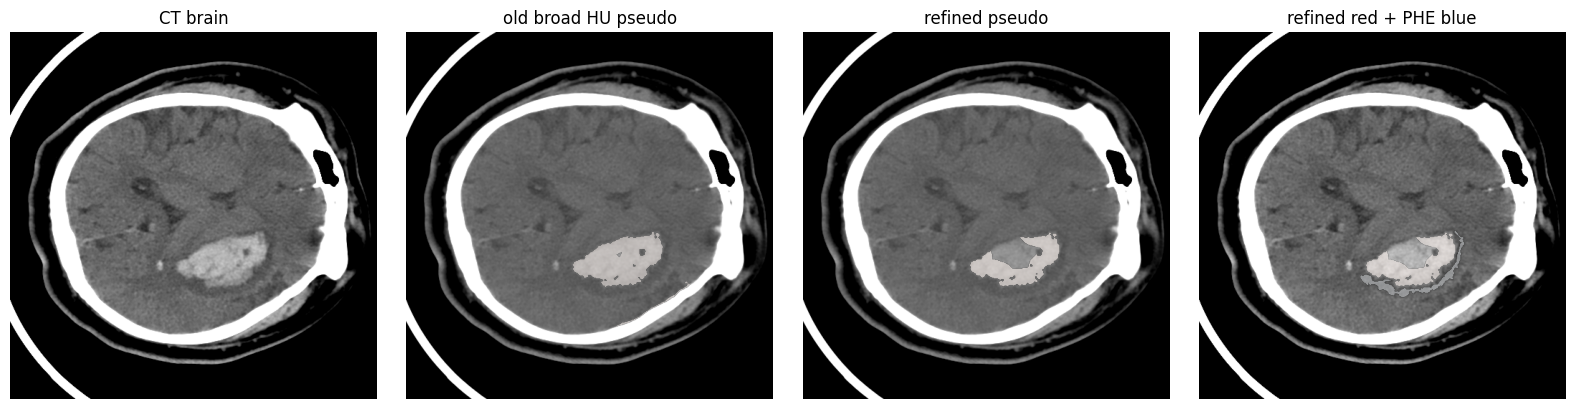

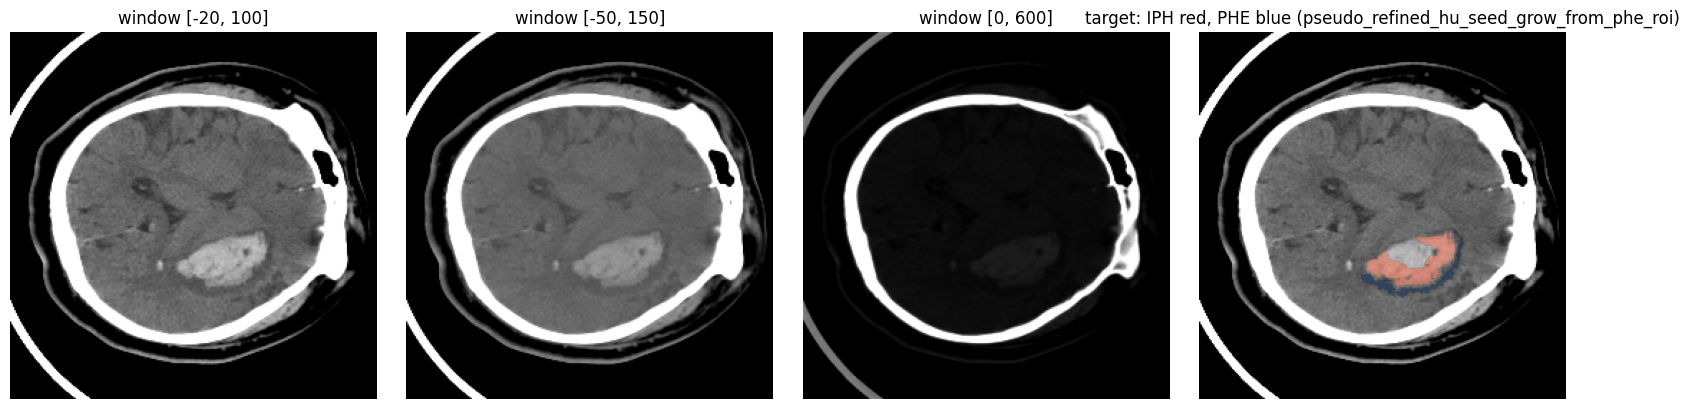

Sample scan: 0006 slice: 15 IPH source: pseudo_refined_hu_seed_grow_from_phe_roi


In [6]:
def window_ct(image: np.ndarray, low: float, high: float) -> np.ndarray:
    image = image.astype(np.float32, copy=False)
    image = np.clip(image, low, high)
    return ((image - low) / max(high - low, 1e-6)).astype(np.float32)


def resize_2d(array: np.ndarray, out_size: int, order: int = 1) -> np.ndarray:
    if array.shape[-2:] == (out_size, out_size):
        return array
    if not SCIPY_AVAILABLE:
        raise ImportError("Install scipy for resizing.")
    zoom_y = out_size / array.shape[-2]
    zoom_x = out_size / array.shape[-1]
    return ndimage.zoom(array, (zoom_y, zoom_x), order=order)


def make_25d_multiwindow_stack(volume: np.ndarray, z: int, image_size: int = CFG.image_size) -> np.ndarray:
    # Returns [D, C_window, H, W].
    n_slices = volume.shape[2]
    depth_items = []
    for off in CFG.slice_offsets:
        zi = int(np.clip(z + int(off), 0, n_slices - 1))
        channels = []
        for low, high in CFG.ct_windows:
            x = window_ct(np.asarray(volume[:, :, zi]), low, high)
            channels.append(resize_2d(x, image_size, order=1))
        depth_items.append(np.stack(channels, axis=0))
    return np.stack(depth_items, axis=0).astype(np.float32)


def preprocess_target_slice(target_volume: np.ndarray, z: int, image_size: int = CFG.image_size) -> np.ndarray:
    y = np.asarray(target_volume[:, :, z]).astype(np.uint8)
    return resize_2d(y, image_size, order=0).astype(np.int64)


def largest_label_slice(mask_volume: np.ndarray) -> int:
    fg = mask_volume > 0
    per_slice = fg.reshape((-1, fg.shape[2])).sum(axis=0)
    return int(np.argmax(per_slice))


def remove_small_components(mask: np.ndarray, spacing: Tuple[float, float, float], min_ml: float, max_components: Optional[int] = None) -> np.ndarray:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return mask
    labeled, n = ndimage.label(mask)
    if n == 0:
        return mask
    sizes = np.bincount(labeled.ravel()).astype(np.float64)
    sizes[0] = 0.0
    min_voxels = max(1, int(round((float(min_ml) * 1000.0) / max(np.prod(spacing), 1e-6))))
    candidates = np.where(sizes >= min_voxels)[0]
    candidates = candidates[candidates != 0]
    if len(candidates) == 0:
        return np.zeros_like(mask, dtype=bool)
    order = candidates[np.argsort(sizes[candidates])[::-1]]
    if max_components is not None:
        order = order[: int(max_components)]
    keep = np.zeros(n + 1, dtype=bool)
    keep[order] = True
    return keep[labeled]


def dilate_mm(mask: np.ndarray, spacing: Tuple[float, float, float], radius_mm: float) -> np.ndarray:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return mask
    # Distance transform of the complement gives distance to the nearest positive voxel.
    dist = ndimage.distance_transform_edt(~mask, sampling=spacing)
    return dist <= float(radius_mm)


def volume_ml(mask: np.ndarray, spacing: Tuple[float, float, float]) -> float:
    return float(mask.astype(bool).sum() * np.prod(spacing) / 1000.0)


def load_true_iph_if_available(row: pd.Series):
    if CFG.true_iph_mask_dir is None:
        return None
    mask_dir = Path(CFG.true_iph_mask_dir)
    candidates = [
        mask_dir / Path(row["phe_mask_path"]).name,
        mask_dir / f"{row['scan_id']}.nii.gz",
        mask_dir / f"{row['scan_id']}.nii",
    ]
    for path in candidates:
        if path.exists():
            mask, _, _ = load_nifti(path)
            return mask > 0
    return None


def generate_legacy_pseudo_iph(volume: np.ndarray, phe_mask: np.ndarray, spacing: Tuple[float, float, float]) -> np.ndarray:
    """Original broad HU/PHE-dilation pseudo rule, kept only for visual comparison."""
    phe = phe_mask.astype(bool)
    roi = dilate_mm(phe, spacing, 18.0)
    hu_candidate = np.isfinite(volume) & (volume >= 40.0) & (volume <= 100.0)
    candidate = hu_candidate & roi & (~phe)
    return remove_small_components(candidate, spacing, min_ml=0.03, max_components=3).astype(bool)


def phe_bbox_roi(phe: np.ndarray, spacing: Tuple[float, float, float], margin_mm: float, z_margin: int) -> np.ndarray:
    """Constrain pseudo IPH to a case-local neighborhood around the manual PHE mask."""
    phe = phe.astype(bool)
    roi = np.zeros_like(phe, dtype=bool)
    if phe.sum() == 0:
        return roi
    coords = np.where(phe)
    margins = [int(np.ceil(float(margin_mm) / max(float(spacing[i]), 1e-6))) for i in range(3)]
    margins[2] = int(max(z_margin, margins[2] // 2))
    slices = []
    for axis, values in enumerate(coords):
        lo = max(0, int(values.min()) - margins[axis])
        hi = min(phe.shape[axis], int(values.max()) + margins[axis] + 1)
        slices.append(slice(lo, hi))
    roi[tuple(slices)] = True
    return roi


def component_physical_stats(mask: np.ndarray, component: np.ndarray, spacing: Tuple[float, float, float]) -> Dict:
    coords = np.where(component)
    if len(coords[0]) == 0:
        return {"long_axis_mm": 0.0, "extent": 0.0}
    axis_lengths = []
    bbox_voxels = 1
    for axis, values in enumerate(coords):
        length_vox = int(values.max() - values.min() + 1)
        bbox_voxels *= max(1, length_vox)
        axis_lengths.append(length_vox * float(spacing[axis]))
    return {
        "long_axis_mm": float(max(axis_lengths)),
        "extent": float(component.sum() / max(bbox_voxels, 1)),
    }


def select_refined_components(
    candidate: np.ndarray,
    seed: np.ndarray,
    volume: np.ndarray,
    phe: np.ndarray,
    dist_to_phe: np.ndarray,
    spacing: Tuple[float, float, float],
) -> np.ndarray:
    labeled, n = ndimage.label(candidate.astype(bool))
    if n == 0:
        return np.zeros_like(candidate, dtype=bool)

    voxel_ml = float(np.prod(spacing) / 1000.0)
    keep_rows = []
    contact_shell = dist_to_phe <= float(CFG.pseudo_contact_mm)

    for label_id in range(1, n + 1):
        comp = labeled == label_id
        voxels = int(comp.sum())
        ml = float(voxels * voxel_ml)
        if ml < float(CFG.pseudo_min_component_ml):
            continue
        if ml > float(CFG.pseudo_max_component_ml):
            continue

        seed_voxels = int(np.logical_and(comp, seed).sum())
        if seed_voxels < int(CFG.pseudo_min_seed_voxels):
            continue

        hu_values = volume[comp]
        mean_hu = float(np.nanmean(hu_values)) if hu_values.size else 0.0
        if mean_hu < float(CFG.pseudo_min_mean_hu):
            continue

        phys = component_physical_stats(candidate, comp, spacing)
        if phys["long_axis_mm"] > float(CFG.pseudo_max_long_axis_mm):
            continue
        if ml > 0.5 and phys["extent"] < float(CFG.pseudo_min_extent_large_component):
            continue

        contact_ratio = float(np.logical_and(comp, contact_shell).sum() / max(voxels, 1))
        min_dist = float(np.min(dist_to_phe[comp])) if voxels else np.inf
        phe_touch = int(np.logical_and(dilate_mm(comp, spacing, CFG.pseudo_contact_mm), phe).sum())

        # Prefer compact high-HU components that seed strongly and touch/approach PHE.
        score = (
            4.0 * np.log1p(seed_voxels)
            + 2.0 * np.log1p(voxels)
            + 3.0 * contact_ratio
            + 0.05 * mean_hu
            - 0.35 * min_dist
            + (1.5 if phe_touch > 0 else 0.0)
        )
        keep_rows.append((score, label_id, ml, mean_hu, seed_voxels, contact_ratio, min_dist))

    if not keep_rows:
        return np.zeros_like(candidate, dtype=bool)

    keep_rows = sorted(keep_rows, reverse=True)[: int(CFG.pseudo_max_components)]
    keep_ids = {label_id for _, label_id, *_ in keep_rows}
    return np.isin(labeled, list(keep_ids))


def generate_pseudo_iph_with_debug(volume: np.ndarray, phe_mask: np.ndarray, spacing: Tuple[float, float, float]):
    """Refined HU pseudo hemorrhage.

    The old rule used every 40-100 HU voxel inside a wide PHE dilation. That was sensitive to
    vessels, calcifications, and unrelated dense structures. This version:
    1. builds a tight seed ROI near PHE,
    2. grows only through a slightly larger HU/ROI mask,
    3. limits candidates to a PHE-centered bbox and nearby slices,
    4. removes PHE overlap,
    5. keeps only plausible compact/contacting components.
    """
    phe = phe_mask.astype(bool)
    if phe.sum() == 0:
        empty = np.zeros_like(phe, dtype=bool)
        return empty, {"reason": "empty_phe"}

    finite = np.isfinite(volume)
    dist_to_phe = ndimage.distance_transform_edt(~phe, sampling=spacing)
    seed_roi = dist_to_phe <= float(CFG.pseudo_seed_roi_mm)
    grow_roi = dist_to_phe <= float(CFG.pseudo_grow_roi_mm)
    bbox_roi = phe_bbox_roi(phe, spacing, CFG.pseudo_bbox_margin_mm, CFG.pseudo_z_margin_slices)

    seed_hu = finite & (volume >= CFG.pseudo_seed_hu_low) & (volume <= CFG.pseudo_seed_hu_high)
    grow_hu = finite & (volume >= CFG.pseudo_grow_hu_low) & (volume <= CFG.pseudo_grow_hu_high)

    seed = seed_hu & seed_roi & bbox_roi
    grow_mask = grow_hu & grow_roi & bbox_roi
    if CFG.pseudo_remove_phe_overlap:
        seed = seed & (~phe)
        grow_mask = grow_mask & (~phe)

    if seed.sum() > 0:
        candidate = ndimage.binary_propagation(seed, mask=grow_mask)
    else:
        # Conservative fallback: no low-confidence broad growth when no high-HU seed exists.
        candidate = np.zeros_like(grow_mask, dtype=bool)

    if CFG.pseudo_fill_holes and candidate.sum() > 0:
        candidate = ndimage.binary_closing(
            candidate,
            structure=ndimage.generate_binary_structure(3, 1),
            iterations=1,
        )
        candidate = candidate & grow_mask
        candidate = ndimage.binary_fill_holes(candidate) & grow_mask

    refined = select_refined_components(candidate, seed, volume, phe, dist_to_phe, spacing)
    debug = {
        "seed_voxels": int(seed.sum()),
        "grow_voxels": int(grow_mask.sum()),
        "candidate_voxels": int(candidate.sum()),
        "refined_voxels": int(refined.sum()),
        "candidate_ml": float(volume_ml(candidate, spacing)),
        "refined_ml": float(volume_ml(refined, spacing)),
    }
    return refined.astype(bool), debug


def generate_pseudo_iph(volume: np.ndarray, phe_mask: np.ndarray, spacing: Tuple[float, float, float]) -> np.ndarray:
    pseudo, _ = generate_pseudo_iph_with_debug(volume, phe_mask, spacing)
    return pseudo.astype(bool)


def build_multiclass_target(row: pd.Series, image: Optional[np.ndarray] = None, phe_mask: Optional[np.ndarray] = None, spacing: Optional[Tuple[float, float, float]] = None):
    if image is None:
        image, spacing, _ = load_nifti(Path(row["img_path"]))
    if phe_mask is None:
        phe_mask, _, _ = load_nifti(Path(row["phe_mask_path"]))
    if spacing is None:
        _, spacing, _ = load_nifti(Path(row["img_path"]))

    phe = phe_mask > 0
    iph = load_true_iph_if_available(row)
    label_source_iph = "manual_or_external"
    if iph is None:
        iph = generate_pseudo_iph(image, phe, spacing)
        label_source_iph = "pseudo_refined_hu_seed_grow_from_phe_roi"

    target = np.zeros(phe.shape, dtype=np.uint8)
    target[iph.astype(bool)] = 1
    target[phe.astype(bool)] = 2
    return target, label_source_iph


# Visual sanity check for refined pseudo IPH and manual PHE.
sample_row = train_rows.sort_values("phe_volume_ml", ascending=False).iloc[0]
image, spacing, _ = load_nifti(Path(sample_row["img_path"]))
phe_mask, _, _ = load_nifti(Path(sample_row["phe_mask_path"]))
legacy_pseudo = generate_legacy_pseudo_iph(image, phe_mask > 0, spacing)
refined_pseudo, refined_debug = generate_pseudo_iph_with_debug(image, phe_mask > 0, spacing)
target, iph_source = build_multiclass_target(sample_row, image=image, phe_mask=phe_mask, spacing=spacing)
z = largest_label_slice((phe_mask > 0) | legacy_pseudo | refined_pseudo)
print("Pseudo comparison sample:", sample_row["scan_id"], refined_debug)
print("Legacy pseudo ml:", volume_ml(legacy_pseudo, spacing), "Refined pseudo ml:", volume_ml(refined_pseudo, spacing))

fig_cmp, axes_cmp = plt.subplots(1, 4, figsize=(16, 4))
brain = window_ct(np.asarray(image[:, :, z]), -20, 100)
blood = window_ct(np.asarray(image[:, :, z]), -50, 150)
for ax in axes_cmp:
    ax.axis("off")
axes_cmp[0].imshow(brain, cmap="gray")
axes_cmp[0].set_title("CT brain")
axes_cmp[1].imshow(blood, cmap="gray")
axes_cmp[1].imshow(np.ma.masked_where(~legacy_pseudo[:, :, z], legacy_pseudo[:, :, z]), cmap="Reds", alpha=0.45)
axes_cmp[1].set_title("old broad HU pseudo")
axes_cmp[2].imshow(blood, cmap="gray")
axes_cmp[2].imshow(np.ma.masked_where(~refined_pseudo[:, :, z], refined_pseudo[:, :, z]), cmap="Reds", alpha=0.55)
axes_cmp[2].set_title("refined pseudo")
axes_cmp[3].imshow(brain, cmap="gray")
axes_cmp[3].imshow(np.ma.masked_where((phe_mask[:, :, z] <= 0), phe_mask[:, :, z]), cmap="Blues", alpha=0.40)
axes_cmp[3].imshow(np.ma.masked_where(~refined_pseudo[:, :, z], refined_pseudo[:, :, z]), cmap="Reds", alpha=0.50)
axes_cmp[3].set_title("refined red + PHE blue")
plt.tight_layout()
plt.savefig(FIG_DIR / "3dff_refined_vs_legacy_pseudo_sample.png", dpi=160, bbox_inches="tight")
plt.show()

x_small = make_25d_multiwindow_stack(image, z, image_size=256)
y_small = preprocess_target_slice(target, z, image_size=256)

fig, axes = plt.subplots(1, len(CFG.ct_windows) + 1, figsize=(4 * (len(CFG.ct_windows) + 1), 4))
mid = len(CFG.slice_offsets) // 2
for c, (low, high) in enumerate(CFG.ct_windows):
    axes[c].imshow(x_small[mid, c], cmap="gray")
    axes[c].set_title(f"window [{low:g}, {high:g}]")
    axes[c].axis("off")
axes[-1].imshow(x_small[mid, 0], cmap="gray")
axes[-1].imshow(np.ma.masked_where(y_small != 1, y_small), cmap="Reds", alpha=0.50, vmin=0, vmax=2)
axes[-1].imshow(np.ma.masked_where(y_small != 2, y_small), cmap="Blues", alpha=0.45, vmin=0, vmax=2)
axes[-1].set_title(f"target: IPH red, PHE blue ({iph_source})")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "3dff_sample_multiclass_target_refined_pseudo.png", dpi=160, bbox_inches="tight")
plt.show()
print("Sample scan:", sample_row["scan_id"], "slice:", z, "IPH source:", iph_source)


### Refined pseudo-label policy\n\nThe training target still has classes `background/IPH/PHE`, but IPH now means `pseudo_refined_hu_seed_grow_from_phe_roi`. Treat all IPH metrics as pseudo-label metrics. The PHE class remains supervised by the manual PHE mask.

## 5. Benchmark-compatible metrics


In [7]:
def diagonal_distance(shape: Sequence[int], sampling: Optional[Sequence[float]] = None) -> float:
    if sampling is None:
        sampling = [1.0] * len(shape)
    return float(math.sqrt(sum(((int(s) - 1) * float(sp)) ** 2 for s, sp in zip(shape, sampling))))


def confusion_counts(pred: np.ndarray, target: np.ndarray):
    pred = pred.astype(bool)
    target = target.astype(bool)
    tp = int(np.logical_and(pred, target).sum())
    fp = int(np.logical_and(pred, ~target).sum())
    fn = int(np.logical_and(~pred, target).sum())
    tn = int(np.logical_and(~pred, ~target).sum())
    return tp, fp, fn, tn


def overlap_metrics(pred: np.ndarray, target: np.ndarray) -> Dict:
    pred = pred.astype(bool)
    target = target.astype(bool)
    tp, fp, fn, tn = confusion_counts(pred, target)
    pred_pos = tp + fp
    target_pos = tp + fn
    union = tp + fp + fn
    if target_pos == 0 and pred_pos == 0:
        dice = np.nan
        jaccard = np.nan
        precision = np.nan
        recall = np.nan
    else:
        dice = float((2 * tp) / (2 * tp + fp + fn)) if (2 * tp + fp + fn) else np.nan
        jaccard = float(tp / union) if union else np.nan
        precision = float(tp / pred_pos) if pred_pos else 0.0
        recall = float(tp / target_pos) if target_pos else np.nan
    specificity = float(tn / (tn + fp)) if (tn + fp) else np.nan
    return {
        "dice": dice,
        "jaccard": jaccard,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }


def surface_mask(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return mask
    structure = ndimage.generate_binary_structure(mask.ndim, 1)
    eroded = ndimage.binary_erosion(mask, structure=structure, border_value=0)
    return np.logical_xor(mask, eroded)


def surface_distances(pred: np.ndarray, target: np.ndarray, sampling: Sequence[float]):
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 or target.sum() == 0:
        return None, None
    sp = surface_mask(pred)
    st = surface_mask(target)
    if sp.sum() == 0 or st.sum() == 0:
        return None, None
    dt_to_target = ndimage.distance_transform_edt(~st, sampling=sampling)
    dt_to_pred = ndimage.distance_transform_edt(~sp, sampling=sampling)
    return dt_to_target[sp], dt_to_pred[st]


def distance_metrics(pred: np.ndarray, target: np.ndarray, sampling: Sequence[float], empty_penalty: bool = True) -> Dict:
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 and target.sum() == 0:
        return {"hd_mm": np.nan, "hd95_mm": np.nan, "assd_mm": np.nan}
    if pred.sum() == 0 or target.sum() == 0:
        penalty = diagonal_distance(pred.shape, sampling) if empty_penalty else np.inf
        return {"hd_mm": penalty, "hd95_mm": penalty, "assd_mm": penalty}
    d_pred_to_target, d_target_to_pred = surface_distances(pred, target, sampling)
    if d_pred_to_target is None or d_target_to_pred is None:
        penalty = diagonal_distance(pred.shape, sampling) if empty_penalty else np.inf
        return {"hd_mm": penalty, "hd95_mm": penalty, "assd_mm": penalty}
    all_d = np.concatenate([d_pred_to_target, d_target_to_pred]).astype(float)
    return {
        "hd_mm": float(np.max(all_d)),
        "hd95_mm": float(np.percentile(all_d, 95)),
        "assd_mm": float(np.mean(all_d)),
    }


def normalized_surface_dice(pred: np.ndarray, target: np.ndarray, spacing: Tuple[float, float, float], tolerance_mm: float = CFG.nsd_tolerance_mm) -> float:
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 and target.sum() == 0:
        return np.nan
    if pred.sum() == 0 or target.sum() == 0:
        return 0.0
    d_pred_to_target, d_target_to_pred = surface_distances(pred, target, spacing)
    if d_pred_to_target is None or d_target_to_pred is None:
        return 0.0
    close_pred = int((d_pred_to_target <= tolerance_mm).sum())
    close_target = int((d_target_to_pred <= tolerance_mm).sum())
    denom = int(len(d_pred_to_target) + len(d_target_to_pred))
    return float((close_pred + close_target) / denom) if denom else np.nan


def volume_ml(mask: np.ndarray, spacing: Tuple[float, float, float]) -> float:
    return float(mask.astype(bool).sum() * np.prod(spacing) / 1000.0)


def rvd_signed(pred: np.ndarray, target: np.ndarray) -> float:
    pred_vox = float(pred.astype(bool).sum())
    target_vox = float(target.astype(bool).sum())
    if target_vox == 0:
        return np.nan if pred_vox == 0 else np.inf
    return float((pred_vox - target_vox) / target_vox)


def rvd_abs(pred: np.ndarray, target: np.ndarray) -> float:
    value = rvd_signed(pred, target)
    return float(abs(value)) if np.isfinite(value) else value


def r2_score_np(y_true: Sequence[float], y_pred: Sequence[float]) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 2:
        return np.nan
    ss_res = float(((y_true - y_pred) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan


def evaluate_volume_multiclass(scan_id: str, pred_label: np.ndarray, target_label: np.ndarray, spacing: Tuple[float, float, float], label_source_iph: str = "unknown") -> pd.DataFrame:
    rows = []
    for class_id in CLASS_IDS:
        pred = pred_label == class_id
        target = target_label == class_id
        overlap = overlap_metrics(pred, target)
        dist = distance_metrics(pred, target, sampling=spacing, empty_penalty=True)
        pred_ml = volume_ml(pred, spacing)
        target_ml = volume_ml(target, spacing)
        rows.append({
            "scan_id": scan_id,
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "label_source": label_source_iph if class_id == 1 else "manual",
            "gt_positive": bool(target.sum() > 0),
            "pred_positive": bool(pred.sum() > 0),
            "detected": bool(pred.sum() > 0) if target.sum() > 0 else np.nan,
            "false_positive_case": bool(pred.sum() > 0) if target.sum() == 0 else np.nan,
            "dsc": overlap["dice"],
            "jaccard": overlap["jaccard"],
            "precision": overlap["precision"],
            "recall": overlap["recall"],
            "specificity": overlap["specificity"],
            "hd_mm": dist["hd_mm"],
            "hd95_mm": dist["hd95_mm"],
            "assd_mm": dist["assd_mm"],
            "nsd_1mm": normalized_surface_dice(pred, target, spacing, tolerance_mm=CFG.nsd_tolerance_mm),
            "pred_volume_ml": pred_ml,
            "target_volume_ml": target_ml,
            "volume_abs_error_ml": abs(pred_ml - target_ml),
            "volume_sq_error_ml2": (pred_ml - target_ml) ** 2,
            "rvd": rvd_abs(pred, target),
            "rvd_signed": rvd_signed(pred, target),
            **{k: overlap[k] for k in ["tp", "fp", "fn", "tn"]},
        })
    return pd.DataFrame(rows)


def evaluate_slice_multiclass(scan_id: str, pred_label: np.ndarray, target_label: np.ndarray, spacing: Tuple[float, float, float], positive_gt_only: bool = False) -> pd.DataFrame:
    rows = []
    for z in range(target_label.shape[2]):
        for class_id in CLASS_IDS:
            pred = pred_label[:, :, z] == class_id
            target = target_label[:, :, z] == class_id
            if positive_gt_only and target.sum() == 0:
                continue
            overlap = overlap_metrics(pred, target)
            dist = distance_metrics(pred, target, sampling=spacing[:2], empty_penalty=True)
            rows.append({
                "scan_id": scan_id,
                "slice_idx": z,
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "gt_positive": bool(target.sum() > 0),
                "pred_positive": bool(pred.sum() > 0),
                "dice": overlap["dice"],
                "jaccard": overlap["jaccard"],
                "precision": overlap["precision"],
                "recall": overlap["recall"],
                "hd_mm": dist["hd_mm"],
                "hd95_mm": dist["hd95_mm"],
            })
    return pd.DataFrame(rows)


def summarize_metrics(df: pd.DataFrame, group_name: str, cols: Optional[List[str]] = None, group_cols: Sequence[str] = ("class_name",)) -> pd.DataFrame:
    cols = cols or ["dsc", "jaccard", "precision", "recall", "hd95_mm", "assd_mm", "nsd_1mm", "rvd", "volume_abs_error_ml"]
    rows = []
    grouped = df.groupby(list(group_cols), dropna=False) if group_cols else [((), df)]
    for keys, part in grouped:
        if not isinstance(keys, tuple):
            keys = (keys,)
        base = {"group": group_name}
        for name, value in zip(group_cols, keys):
            base[name] = value
        for col in cols:
            if col not in part.columns:
                continue
            values = pd.to_numeric(part[col], errors="coerce")
            finite = values.replace([np.inf, -np.inf], np.nan)
            rows.append({
                **base,
                "metric": col,
                "mean": finite.mean(),
                "std": finite.std(),
                "median": finite.median(),
                "n": int(finite.notna().sum()),
                "n_inf": int(np.isinf(values).sum()),
            })
    return pd.DataFrame(rows)


## 6. Metric sanity checks


In [8]:
# These checks catch common mistakes before paper-style reporting.
a = np.zeros((16, 16, 8), dtype=np.uint8)
b = np.zeros_like(a)
a[4:10, 4:10, 2:5] = 1
b[4:10, 4:10, 2:5] = 1
same = evaluate_volume_multiclass("unit_same", a, b, spacing=(1.0, 1.0, 2.0))
assert np.isclose(same.loc[same.class_id == 1, "dsc"].iloc[0], 1.0)
assert np.isclose(same.loc[same.class_id == 1, "hd95_mm"].iloc[0], 0.0)

c = np.zeros_like(a)
c[5:11, 4:10, 2:5] = 1
shifted = evaluate_volume_multiclass("unit_shifted", c, b, spacing=(1.0, 1.0, 2.0))
assert shifted.loc[shifted.class_id == 1, "dsc"].iloc[0] < 1.0
assert shifted.loc[shifted.class_id == 1, "hd95_mm"].iloc[0] > 0.0

empty = np.zeros_like(a)
empty_case = evaluate_volume_multiclass("unit_empty", empty, empty, spacing=(1.0, 1.0, 2.0))
assert np.isnan(empty_case.loc[empty_case.class_id == 1, "dsc"].iloc[0])

missed = evaluate_volume_multiclass("unit_missed", empty, b, spacing=(1.0, 1.0, 2.0))
assert np.isclose(missed.loc[missed.class_id == 1, "dsc"].iloc[0], 0.0)
assert missed.loc[missed.class_id == 1, "hd95_mm"].iloc[0] > 0.0

print("Metric sanity checks passed.")


Metric sanity checks passed.


## 7. Dataset


In [9]:
if TORCH_AVAILABLE:
    class BrainLesion25DDataset(Dataset):
        def __init__(self, df: pd.DataFrame, image_size: int = CFG.image_size, augment: bool = False):
            self.df = df.copy().reset_index(drop=True)
            self.image_size = int(image_size)
            self.augment = bool(augment)
            self.cache = {}
            self.slice_df = self._build_slice_index()

        def _load_case(self, row_idx: int):
            if row_idx not in self.cache:
                row = self.df.iloc[row_idx]
                image, spacing, _ = load_nifti(Path(row["img_path"]))
                phe_mask, _, _ = load_nifti(Path(row["phe_mask_path"]))
                target, iph_source = build_multiclass_target(row, image=image, phe_mask=phe_mask, spacing=spacing)
                self.cache[row_idx] = (image.astype(np.float32), target.astype(np.uint8), spacing, iph_source)
            return self.cache[row_idx]

        def _build_slice_index(self):
            rows = []
            for row_idx, row in tqdm(list(self.df.iterrows()), desc="index slices", leave=False):
                image, target, spacing, iph_source = self._load_case(int(row_idx))
                n = target.shape[2]
                for z in range(n):
                    iph_pixels = int((target[:, :, z] == 1).sum())
                    phe_pixels = int((target[:, :, z] == 2).sum())
                    rows.append({
                        "row_idx": int(row_idx),
                        "scan_id": row["scan_id"],
                        "slice_idx": int(z),
                        "positive": bool((iph_pixels + phe_pixels) > 0),
                        "positive_iph": bool(iph_pixels > 0),
                        "positive_phe": bool(phe_pixels > 0),
                        "iph_pixels": iph_pixels,
                        "phe_pixels": phe_pixels,
                        "iph_source": iph_source,
                    })
            return pd.DataFrame(rows)

        def _augment(self, x: np.ndarray, y: np.ndarray):
            # x: [D, C, H, W], y: [H, W]
            if random.random() < 0.5:
                x = np.flip(x, axis=3).copy()
                y = np.flip(y, axis=1).copy()
            if random.random() < 0.18:
                angle = random.uniform(-8.0, 8.0)
                flat = x.reshape((-1, x.shape[-2], x.shape[-1]))
                flat = np.stack([ndimage.rotate(ch, angle, reshape=False, order=1, mode="nearest") for ch in flat], axis=0)
                x = flat.reshape(x.shape)
                y = ndimage.rotate(y, angle, reshape=False, order=0, mode="nearest")
            if random.random() < 0.15:
                gamma = random.uniform(0.90, 1.10)
                x = np.clip(x, 0, 1) ** gamma
            if random.random() < 0.12:
                x = np.clip(x + np.random.normal(0, 0.010, size=x.shape).astype(np.float32), 0, 1)
            return x.astype(np.float32), y.astype(np.int64)

        def __len__(self):
            return len(self.slice_df)

        def __getitem__(self, idx):
            item = self.slice_df.iloc[idx]
            image, target, spacing, iph_source = self._load_case(int(item["row_idx"]))
            z = int(item["slice_idx"])
            x = make_25d_multiwindow_stack(image, z, self.image_size)
            y = preprocess_target_slice(target, z, self.image_size)
            if self.augment:
                x, y = self._augment(x, y)
            return {
                "image": torch.from_numpy(x).float(),
                "target": torch.from_numpy(y).long(),
                "scan_id": str(item["scan_id"]),
                "slice_idx": int(z),
                "spacing": torch.tensor(spacing, dtype=torch.float32),
                "positive": bool(item["positive"]),
            }
else:
    print("Torch unavailable. Dataset skipped.")


## 8. Model: 3DFF-Net


In [10]:
if TORCH_AVAILABLE and TORCHVISION_AVAILABLE:
    def load_resnet18_backbone():
        weights = None
        if CFG.pretrained_backbone:
            try:
                weights = ResNet18_Weights.DEFAULT
            except Exception:
                weights = None
        try:
            model = resnet18(weights=weights)
            print("ResNet18 weights:", "ImageNet" if weights is not None else "random")
        except Exception as exc:
            print("Could not load pretrained ResNet18; falling back to random:", exc)
            model = resnet18(weights=None)
        return model


    class SliceResNet18Encoder(nn.Module):
        def __init__(self):
            super().__init__()
            base = load_resnet18_backbone()
            self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
            self.layer1 = base.layer1
            self.layer2 = base.layer2
            self.layer3 = base.layer3
            self.layer4 = base.layer4

        def forward(self, x):
            x = self.stem(x)
            c2 = self.layer1(x)
            c3 = self.layer2(c2)
            c4 = self.layer3(c3)
            c5 = self.layer4(c4)
            return {"c2": c2, "c3": c3, "c4": c4, "c5": c5}


    def gn(channels: int):
        groups = 8
        while channels % groups != 0 and groups > 1:
            groups //= 2
        return nn.GroupNorm(groups, channels)


    class Depthwise3DFeatureFusion(nn.Module):
        def __init__(self, channels: int, depth: int):
            super().__init__()
            self.depthwise = nn.Conv3d(channels, channels, kernel_size=(depth, 1, 1), groups=channels, bias=False)
            self.pointwise = nn.Sequential(
                nn.Conv2d(channels, channels, kernel_size=1, bias=False),
                gn(channels),
                nn.SiLU(inplace=True),
            )

        def forward(self, x):
            # x: [B, D, C, H, W]
            x = x.permute(0, 2, 1, 3, 4).contiguous()
            x = self.depthwise(x).squeeze(2)
            return self.pointwise(x)


    class FPN(nn.Module):
        def __init__(self, in_channels=(64, 128, 256, 512), out_channels=CFG.fpn_channels):
            super().__init__()
            self.laterals = nn.ModuleList([nn.Conv2d(c, out_channels, 1) for c in in_channels])
            self.smooth = nn.ModuleList([
                nn.Sequential(nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False), gn(out_channels), nn.SiLU(inplace=True))
                for _ in in_channels
            ])

        def forward(self, feats: Dict[str, torch.Tensor]):
            c2, c3, c4, c5 = feats["c2"], feats["c3"], feats["c4"], feats["c5"]
            lat = [l(f) for l, f in zip(self.laterals, [c2, c3, c4, c5])]
            p5 = lat[3]
            p4 = lat[2] + F.interpolate(p5, size=lat[2].shape[-2:], mode="nearest")
            p3 = lat[1] + F.interpolate(p4, size=lat[1].shape[-2:], mode="nearest")
            p2 = lat[0] + F.interpolate(p3, size=lat[0].shape[-2:], mode="nearest")
            return {
                "p2": self.smooth[0](p2),
                "p3": self.smooth[1](p3),
                "p4": self.smooth[2](p4),
                "p5": self.smooth[3](p5),
            }


    class ConvGNAct(nn.Module):
        def __init__(self, in_ch, out_ch, dropout=0.0):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                gn(out_ch),
                nn.SiLU(inplace=True),
                nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                gn(out_ch),
                nn.SiLU(inplace=True),
            )

        def forward(self, x):
            return self.net(x)


    class SegmentationDecoder(nn.Module):
        def __init__(self, fpn_channels=CFG.fpn_channels, decoder_channels=CFG.decoder_channels, out_classes=CFG.num_classes):
            super().__init__()
            d0, d1, d2, d3 = decoder_channels
            self.fuse = ConvGNAct(fpn_channels * 4, d0, dropout=0.08)
            self.up1 = ConvGNAct(d0, d1, dropout=0.05)
            self.up2 = ConvGNAct(d1, d2, dropout=0.03)
            self.up3 = ConvGNAct(d2, d3, dropout=0.02)
            self.head = nn.Conv2d(d3, out_classes, 1)

        def forward(self, pyramid: Dict[str, torch.Tensor]):
            p2 = pyramid["p2"]
            target_size = p2.shape[-2:]
            p3 = F.interpolate(pyramid["p3"], size=target_size, mode="bilinear", align_corners=False)
            p4 = F.interpolate(pyramid["p4"], size=target_size, mode="bilinear", align_corners=False)
            p5 = F.interpolate(pyramid["p5"], size=target_size, mode="bilinear", align_corners=False)
            x = self.fuse(torch.cat([p2, p3, p4, p5], dim=1))
            x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
            x = self.up1(x)
            x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
            x = self.up2(x)
            x = self.up3(x)
            return self.head(x)


    class ThreeDFFNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.encoder = SliceResNet18Encoder()
            depth = len(CFG.slice_offsets)
            self.fusions = nn.ModuleDict({
                "c2": Depthwise3DFeatureFusion(64, depth),
                "c3": Depthwise3DFeatureFusion(128, depth),
                "c4": Depthwise3DFeatureFusion(256, depth),
                "c5": Depthwise3DFeatureFusion(512, depth),
            })
            self.fpn = FPN()
            self.decoder = SegmentationDecoder()

        def forward(self, x):
            # x: [B, D, C_window, H, W]
            b, d, c, h, w = x.shape
            x2d = x.reshape(b * d, c, h, w)
            per_slice = self.encoder(x2d)
            fused = {}
            for name, feat in per_slice.items():
                _, ch, fh, fw = feat.shape
                feat = feat.reshape(b, d, ch, fh, fw)
                fused[name] = self.fusions[name](feat)
            pyramid = self.fpn(fused)
            logits = self.decoder(pyramid)
            if logits.shape[-2:] != (h, w):
                logits = F.interpolate(logits, size=(h, w), mode="bilinear", align_corners=False)
            return logits
elif TORCH_AVAILABLE:
    print("Torch is available but torchvision is not. Install torchvision to run 3DFF-Net.")
else:
    print("Torch unavailable. Model skipped.")


## 9. Loss and loaders


In [11]:
if TORCH_AVAILABLE:
    def multiclass_dice_loss(logits, target, class_ids=CLASS_IDS, eps=1e-6):
        probs = torch.softmax(logits, dim=1)
        losses = []
        for class_id in class_ids:
            p = probs[:, class_id]
            t = (target == class_id).float()
            dims = tuple(range(1, p.ndim))
            inter = (p * t).sum(dims)
            denom = p.sum(dims) + t.sum(dims)
            dice = (2 * inter + eps) / (denom + eps)
            losses.append(1.0 - dice)
        return torch.stack(losses, dim=0).mean()


    def boundary_consistency_loss(logits, target):
        probs = torch.softmax(logits, dim=1)[:, 1:, :, :]
        onehot = F.one_hot(target.clamp(0, CFG.num_classes - 1), num_classes=CFG.num_classes).permute(0, 3, 1, 2).float()[:, 1:, :, :]
        px = torch.abs(probs[:, :, :, 1:] - probs[:, :, :, :-1])
        py = torch.abs(probs[:, :, 1:, :] - probs[:, :, :-1, :])
        tx = torch.abs(onehot[:, :, :, 1:] - onehot[:, :, :, :-1])
        ty = torch.abs(onehot[:, :, 1:, :] - onehot[:, :, :-1, :])
        return F.l1_loss(px, tx) + F.l1_loss(py, ty)


    def estimate_class_weights(df: pd.DataFrame) -> np.ndarray:
        counts = np.zeros(CFG.num_classes, dtype=np.float64)
        for _, row in tqdm(df.iterrows(), total=len(df), desc="class weights", leave=False):
            image, spacing, _ = load_nifti(Path(row["img_path"]))
            phe_mask, _, _ = load_nifti(Path(row["phe_mask_path"]))
            target, _ = build_multiclass_target(row, image=image, phe_mask=phe_mask, spacing=spacing)
            vals, cnt = np.unique(target, return_counts=True)
            counts[vals.astype(int)] += cnt.astype(np.float64)
        nonzero = counts[counts > 0]
        median = np.median(nonzero) if len(nonzero) else 1.0
        weights = median / np.maximum(counts, 1.0)
        weights = np.clip(weights, CFG.class_weight_min, CFG.class_weight_max)
        weights[0] = min(weights[0], CFG.background_weight_cap)
        return weights.astype(np.float32)


    def make_loss_fn(class_weights: np.ndarray):
        weight = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

        def loss_fn(logits, target):
            ce = F.cross_entropy(logits, target, weight=weight)
            dice = multiclass_dice_loss(logits, target)
            boundary = boundary_consistency_loss(logits, target)
            return CFG.lambda_ce * ce + CFG.lambda_dice * dice + CFG.lambda_boundary * boundary

        return loss_fn


    def make_loader(ds, batch_size, positive_weight, shuffle=False):
        if shuffle:
            weights = np.where(ds.slice_df["positive"].to_numpy(bool), positive_weight, 1.0).astype(np.float64)
            sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
            return DataLoader(ds, batch_size=batch_size, sampler=sampler, shuffle=False, num_workers=CFG.num_workers, pin_memory=(DEVICE == "cuda"))
        return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=(DEVICE == "cuda"))


if TORCH_AVAILABLE and TORCHVISION_AVAILABLE:
    train_ds = BrainLesion25DDataset(train_rows, CFG.image_size, augment=CFG.augment_train)
    val_ds = BrainLesion25DDataset(val_rows, CFG.image_size, augment=False)
    train_loader = make_loader(train_ds, CFG.batch_size, CFG.positive_slice_weight, shuffle=True)
    val_loader = make_loader(val_ds, CFG.batch_size, CFG.positive_slice_weight, shuffle=False)

    class_weights = estimate_class_weights(train_rows)
    model = ThreeDFFNet().to(DEVICE)
    loss_fn = make_loss_fn(class_weights)
    backbone_params = list(model.encoder.parameters())
    head_params = [p for n, p in model.named_parameters() if not n.startswith("encoder.")]
    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": CFG.lr_backbone},
            {"params": head_params, "lr": CFG.lr_head},
        ],
        weight_decay=CFG.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=6)

    display(pd.DataFrame([
        {"split": "train", "cases": len(train_rows), "slices": len(train_ds), "positive_slices": int(train_ds.slice_df["positive"].sum()), "iph_slices": int(train_ds.slice_df["positive_iph"].sum()), "phe_slices": int(train_ds.slice_df["positive_phe"].sum())},
        {"split": "val", "cases": len(val_rows), "slices": len(val_ds), "positive_slices": int(val_ds.slice_df["positive"].sum()), "iph_slices": int(val_ds.slice_df["positive_iph"].sum()), "phe_slices": int(val_ds.slice_df["positive_phe"].sum())},
        {"split": "test", "cases": len(test_rows), "slices": int(test_rows["n_slices"].sum()), "positive_slices": int(test_rows["phe_positive_slices"].sum()), "iph_slices": np.nan, "phe_slices": int(test_rows["phe_positive_slices"].sum())},
    ]))
    print("class weights:", dict(zip(CLASS_NAMES.values(), class_weights)))
    print("parameters:", sum(p.numel() for p in model.parameters()))
else:
    print("Training setup skipped.")


index slices:   0%|          | 0/48 [00:00<?, ?it/s]

index slices:   0%|          | 0/48 [00:00<?, ?it/s]

class weights:   0%|          | 0/48 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s] 


ResNet18 weights: ImageNet


,split,cases,slices,positive_slices,iph_slices,phe_slices
0,train,48,1368,334,326.0,284
1,val,48,1434,322,322.0,269
2,test,24,799,130,NaN,130


class weights: {'background': np.float32(0.05), 'IPH': np.float32(1.0), 'PHE': np.float32(2.8860514)}
parameters: 13318483


## 10. Train 3DFF-Net


In [12]:
if TORCH_AVAILABLE and TORCHVISION_AVAILABLE:
    def set_backbone_trainable(model, trainable: bool):
        for p in model.encoder.parameters():
            p.requires_grad = bool(trainable)


    def logits_to_label_tensor(logits, foreground_threshold: float):
        probs = torch.softmax(logits, dim=1)
        fg_prob, fg_idx = probs[:, 1:, :, :].max(dim=1)
        label = fg_idx.long() + 1
        label = torch.where(fg_prob >= float(foreground_threshold), label, torch.zeros_like(label))
        return label


    def train_epoch(epoch: int):
        backbone_trainable = epoch > CFG.freeze_backbone_epochs
        set_backbone_trainable(model, backbone_trainable)
        model.train()
        if not backbone_trainable:
            model.encoder.eval()

        scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))
        losses = []
        optimizer.zero_grad(set_to_none=True)
        for step, batch in enumerate(tqdm(train_loader, desc=f"train {epoch}", leave=False), start=1):
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["target"].to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
                logits = model(x)
                loss = loss_fn(logits, y) / max(1, CFG.grad_accum_steps)
            scaler.scale(loss).backward()
            if step % CFG.grad_accum_steps == 0 or step == len(train_loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            losses.append(float(loss.detach().cpu()) * max(1, CFG.grad_accum_steps))
        return float(np.mean(losses)) if losses else np.nan


    @torch.no_grad()
    def validate_slices():
        model.eval()
        losses = []
        class_dices = {class_id: [] for class_id in CLASS_IDS}
        empty_total = 0
        empty_pred = 0
        for batch in tqdm(val_loader, desc="val", leave=False):
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["target"].to(DEVICE, non_blocking=True)
            logits = model(x)
            losses.append(float(loss_fn(logits, y).detach().cpu()))
            pred = logits_to_label_tensor(logits, CFG.foreground_threshold).cpu().numpy()
            target = y.cpu().numpy()
            for i in range(pred.shape[0]):
                if (target[i] > 0).sum() == 0:
                    empty_total += 1
                    empty_pred += int((pred[i] > 0).sum() > 0)
                for class_id in CLASS_IDS:
                    gt = target[i] == class_id
                    if gt.sum() == 0:
                        continue
                    m = overlap_metrics(pred[i] == class_id, gt)
                    class_dices[class_id].append(m["dice"])
        empty_fp_rate = empty_pred / max(empty_total, 1)
        dice_iph = float(np.nanmean(class_dices[1])) if class_dices[1] else np.nan
        dice_phe = float(np.nanmean(class_dices[2])) if class_dices[2] else np.nan
        mean_fg_dice = float(np.nanmean([dice_iph, dice_phe]))
        score = mean_fg_dice - 0.20 * empty_fp_rate if np.isfinite(mean_fg_dice) else np.nan
        return {
            "loss": float(np.mean(losses)) if losses else np.nan,
            "dice_iph_pos": dice_iph,
            "dice_phe_pos": dice_phe,
            "mean_fg_dice": mean_fg_dice,
            "empty_fp_rate": float(empty_fp_rate),
            "score": float(score) if np.isfinite(score) else np.nan,
        }


    best_ckpt = CHECKPOINT_DIR / "3dff_net_iph_phe_best.pt"
    last_ckpt = CHECKPOINT_DIR / "3dff_net_iph_phe_last.pt"

    if CFG.run_training:
        epochs = CFG.debug_epochs if CFG.debug_small_run else CFG.epochs
        history = []
        best = -np.inf
        bad = 0
        for epoch in range(1, epochs + 1):
            t0 = time.time()
            tr_loss = train_epoch(epoch)
            val_m = validate_slices()
            scheduler.step(val_m["score"] if np.isfinite(val_m["score"]) else 0.0)
            row = {
                "epoch": epoch,
                "lr_backbone": optimizer.param_groups[0]["lr"],
                "lr_head": optimizer.param_groups[1]["lr"],
                "backbone_trainable": epoch > CFG.freeze_backbone_epochs,
                "sec": time.time() - t0,
                "train_loss": tr_loss,
                **{f"val_{k}": v for k, v in val_m.items()},
            }
            history.append(row)
            print(row)
            pd.DataFrame(history).to_csv(LOG_DIR / "3dff_training_log.csv", index=False)
            torch.save({"model": model.state_dict(), "cfg": asdict(CFG), "epoch": epoch, "history": history, "class_weights": class_weights}, last_ckpt)

            score = val_m["score"]
            if np.isfinite(score) and score > best + CFG.min_delta:
                best = score
                bad = 0
                torch.save({"model": model.state_dict(), "cfg": asdict(CFG), "epoch": epoch, "best_metric": best, "history": history, "class_weights": class_weights}, best_ckpt)
                print("Saved best:", best_ckpt)
            else:
                bad += 1
            if bad >= CFG.patience:
                print(f"Early stopping at epoch {epoch}; best val score={best:.4f}")
                break
    else:
        print("Training disabled.")
else:
    print("Training skipped.")


/tmp/ipykernel_58/3645523638.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))


train 1:   0%|          | 0/684 [00:00<?, ?it/s]

/tmp/ipykernel_58/3645523638.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):


val:   0%|          | 0/717 [00:00<?, ?it/s]

{'epoch': 1, 'lr_backbone': 1e-05, 'lr_head': 5e-05, 'backbone_trainable': False, 'sec': 380.45536041259766, 'train_loss': 1.1290960414716376, 'val_loss': 1.046923995101136, 'val_dice_iph_pos': 0.5544416134891249, 'val_dice_phe_pos': 0.16613521162558775, 'val_mean_fg_dice': 0.36028841255735633, 'val_empty_fp_rate': 0.22482014388489208, 'val_score': 0.3153243837803779}
Saved best: /kaggle/working/outputs_02_4_3dff_refined_pseudo_iph_phe_25d_segmentation/checkpoints/3dff_net_iph_phe_best.pt


...

val:   0%|          | 0/717 [00:00<?, ?it/s]

{'epoch': 31, 'lr_backbone': 2.5e-06, 'lr_head': 1.25e-05, 'backbone_trainable': True, 'sec': 404.39292645454407, 'train_loss': 0.663979404785654, 'val_loss': 0.9728773652343404, 'val_dice_iph_pos': 0.7338763360094417, 'val_dice_phe_pos': 0.37304333053338945, 'val_mean_fg_dice': 0.5534598332714156, 'val_empty_fp_rate': 0.11780575539568346, 'val_score': 0.5298986821922789}


train 32:   0%|          | 0/684 [00:00<?, ?it/s]

val:   0%|          | 0/717 [00:00<?, ?it/s]

{'epoch': 32, 'lr_backbone': 2.5e-06, 'lr_head': 1.25e-05, 'backbone_trainable': True, 'sec': 410.9980890750885, 'train_loss': 0.6572792337150776, 'val_loss': 0.9652484410560613, 'val_dice_iph_pos': 0.7354523760721532, 'val_dice_phe_pos': 0.3730362340254245, 'val_mean_fg_dice': 0.5542443050487889, 'val_empty_fp_rate': 0.14298561151079137, 'val_score': 0.5256471827466306}
Early stopping at epoch 32; best val score=0.5409


## 11. Inference, post-processing, and threshold tuning


In [13]:
if TORCH_AVAILABLE and TORCHVISION_AVAILABLE:
    def torch_load_checkpoint(path: Path):
        try:
            return torch.load(path, map_location=DEVICE, weights_only=False)
        except TypeError:
            return torch.load(path, map_location=DEVICE)


    def load_best_model():
        ckpt = CHECKPOINT_DIR / "3dff_net_iph_phe_best.pt"
        if not ckpt.exists():
            ckpt = CHECKPOINT_DIR / "3dff_net_iph_phe_last.pt"
        if not ckpt.exists():
            return None, None
        m = ThreeDFFNet().to(DEVICE)
        state = torch_load_checkpoint(ckpt)
        state_dict = state["model"] if isinstance(state, dict) and "model" in state else state
        m.load_state_dict(state_dict)
        m.eval()
        return m, ckpt


    @torch.no_grad()
    def predict_case_probabilities(m, row: pd.Series, image_size: int = CFG.image_size):
        m.eval()
        image, spacing, _ = load_nifti(Path(row["img_path"]))
        probs = []
        for z in range(image.shape[2]):
            x = make_25d_multiwindow_stack(image, z, image_size)
            xb = torch.from_numpy(x[None]).float().to(DEVICE)
            prob = torch.softmax(m(xb), dim=1)[0].detach().cpu().numpy()
            if CFG.use_tta_flip:
                xf = np.flip(x, axis=3).copy()
                xfb = torch.from_numpy(xf[None]).float().to(DEVICE)
                pf = torch.softmax(m(xfb), dim=1)[0].detach().cpu().numpy()
                pf = np.flip(pf, axis=2).copy()
                prob = 0.5 * (prob + pf)
            resized = []
            for class_id in range(CFG.num_classes):
                pc = resize_2d(prob[class_id], image.shape[0], order=1)
                if pc.shape != image.shape[:2]:
                    pc = ndimage.zoom(pc, (image.shape[0] / pc.shape[0], image.shape[1] / pc.shape[1]), order=1)
                resized.append(pc.astype(np.float32))
            resized = np.stack(resized, axis=0)
            resized = np.maximum(resized, 1e-7)
            resized = resized / resized.sum(axis=0, keepdims=True)
            probs.append(resized)
        prob_volume = np.stack(probs, axis=-1)  # [C, H, W, Z]
        return prob_volume, spacing


    def postprocess_label(label: np.ndarray, spacing: Tuple[float, float, float]) -> np.ndarray:
        if not CFG.use_postprocess:
            return label.astype(np.uint8)
        out = np.zeros_like(label, dtype=np.uint8)
        for class_id in CLASS_IDS:
            mask = label == class_id
            if class_id == 1:
                mask = remove_small_components(mask, spacing, CFG.min_component_ml_iph, CFG.max_components_iph)
            elif class_id == 2:
                mask = remove_small_components(mask, spacing, CFG.min_component_ml_phe, CFG.max_components_phe)
            out[mask] = class_id
        return out


    def prob_to_label_volume(prob_volume: np.ndarray, foreground_threshold: float, spacing: Tuple[float, float, float]) -> np.ndarray:
        fg_prob = prob_volume[1:, :, :, :].max(axis=0)
        fg_cls = prob_volume[1:, :, :, :].argmax(axis=0).astype(np.uint8) + 1
        label = np.where(fg_prob >= float(foreground_threshold), fg_cls, 0).astype(np.uint8)
        return postprocess_label(label, spacing)


    def load_target_for_row(row: pd.Series):
        image, spacing, _ = load_nifti(Path(row["img_path"]))
        phe_mask, _, _ = load_nifti(Path(row["phe_mask_path"]))
        target, iph_source = build_multiclass_target(row, image=image, phe_mask=phe_mask, spacing=spacing)
        return target, spacing, iph_source


    def fast_score_for_threshold(prob: np.ndarray, target: np.ndarray, spacing, threshold: float, scan_id: str, iph_source: str):
        pred = prob_to_label_volume(prob, threshold, spacing)
        metrics = evaluate_volume_multiclass(scan_id, pred, target, spacing, iph_source)
        pos = metrics[metrics["gt_positive"]].copy()
        dsc_by_class = pos.groupby("class_id")["dsc"].mean().to_dict()
        rvd_by_class = pos.groupby("class_id")["rvd"].mean().to_dict()
        return {
            "dsc_iph": dsc_by_class.get(1, np.nan),
            "dsc_phe": dsc_by_class.get(2, np.nan),
            "rvd_iph": rvd_by_class.get(1, np.nan),
            "rvd_phe": rvd_by_class.get(2, np.nan),
            "volume_mae_ml": float(pos["volume_abs_error_ml"].replace([np.inf, -np.inf], np.nan).mean()),
        }


    eval_model, used_ckpt = load_best_model()
    tuned_threshold = CFG.foreground_threshold
    threshold_table = pd.DataFrame()

    if eval_model is not None and CFG.tune_threshold_on_val:
        cached_val = []
        for _, row in tqdm(val_rows.iterrows(), total=len(val_rows), desc="cache val probs"):
            prob, spacing = predict_case_probabilities(eval_model, row)
            target, _, iph_source = load_target_for_row(row)
            cached_val.append((row["scan_id"], prob, target, spacing, iph_source))

        compact = []
        for threshold in CFG.threshold_grid:
            rows = []
            for scan_id, prob, target, spacing, iph_source in cached_val:
                rows.append(fast_score_for_threshold(prob, target, spacing, threshold, scan_id, iph_source))
            tmp = pd.DataFrame(rows)
            mean_dsc_iph = float(tmp["dsc_iph"].replace([np.inf, -np.inf], np.nan).mean())
            mean_dsc_phe = float(tmp["dsc_phe"].replace([np.inf, -np.inf], np.nan).mean())
            mean_rvd = float(tmp[["rvd_iph", "rvd_phe"]].replace([np.inf, -np.inf], np.nan).stack().mean())
            volume_mae = float(tmp["volume_mae_ml"].replace([np.inf, -np.inf], np.nan).mean())
            mean_fg_dsc = float(np.nanmean([mean_dsc_iph, mean_dsc_phe]))
            score = mean_fg_dsc - 0.03 * mean_rvd - 0.003 * volume_mae
            compact.append({
                "threshold": float(threshold),
                "mean_dsc_iph": mean_dsc_iph,
                "mean_dsc_phe": mean_dsc_phe,
                "mean_fg_dsc": mean_fg_dsc,
                "mean_rvd": mean_rvd,
                "volume_mae_ml": volume_mae,
                "selection_score": float(score),
            })
        threshold_table = pd.DataFrame(compact)
        threshold_table.to_csv(TABLE_DIR / "3dff_val_threshold_sweep.csv", index=False)
        tuned_threshold = float(
            threshold_table.sort_values(
                ["selection_score", "mean_fg_dsc", "volume_mae_ml", "mean_rvd"],
                ascending=[False, False, True, True],
            ).iloc[0]["threshold"]
        )
        print("Loaded checkpoint:", used_ckpt)
        print("Tuned foreground threshold:", tuned_threshold)
        display(threshold_table)
    elif eval_model is None:
        print("No checkpoint found for threshold tuning.")
    else:
        print("Threshold tuning disabled; using", tuned_threshold)

    with open(LOG_DIR / "3dff_threshold.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "foreground_threshold": tuned_threshold,
                "default_foreground_threshold": CFG.foreground_threshold,
                "checkpoint": str(used_ckpt) if used_ckpt else None,
                "selection_metric": "validation mean foreground DSC penalized by RVD and volume MAE",
                "postprocess": {
                    "enabled": CFG.use_postprocess,
                    "min_component_ml_iph": CFG.min_component_ml_iph,
                    "min_component_ml_phe": CFG.min_component_ml_phe,
                    "max_components_iph": CFG.max_components_iph,
                    "max_components_phe": CFG.max_components_phe,
                },
            },
            f,
            ensure_ascii=False,
            indent=2,
        )
else:
    print("Threshold tuning skipped.")


ResNet18 weights: ImageNet


cache val probs:   0%|          | 0/48 [00:00<?, ?it/s]

Loaded checkpoint: /kaggle/working/outputs_02_4_3dff_refined_pseudo_iph_phe_25d_segmentation/checkpoints/3dff_net_iph_phe_best.pt
Tuned foreground threshold: 0.55


,threshold,mean_dsc_iph,mean_dsc_phe,mean_fg_dsc,mean_rvd,volume_mae_ml,selection_score
0,0.30,0.819900,0.354495,0.587198,1.835556,3.107940,0.522807
1,0.35,0.820909,0.353426,0.587167,1.723968,2.940615,0.526626
2,0.40,0.822087,0.355622,0.588855,1.614585,2.770356,0.532106
3,0.45,0.828314,0.356752,0.592533,1.486499,2.564315,0.540245
4,0.50,0.827780,0.358948,0.593364,1.314721,2.344146,0.546890
5,0.55,0.826400,0.355735,0.591068,1.207098,2.198219,0.548260
6,0.60,0.824678,0.351712,0.588195,1.132287,2.098788,0.547930
7,0.65,0.823293,0.348702,0.585997,1.072454,2.038358,0.547708
8,0.70,0.821907,0.340197,0.581052,1.029637,2.001125,0.544159
9,0.75,0.819632,0.336694,0.578163,0.973826,1.974443,0.543025


## 12. Final test evaluation


test volumes:   0%|          | 0/24 [00:00<?, ?it/s]

,group,class_name,metric,mean,std,median,n,n_inf
0,3dff:test_volume_gt_positive,IPH,dsc,0.729341,0.277624,0.850519,23,0
1,3dff:test_volume_gt_positive,IPH,jaccard,0.630229,0.273838,0.739915,23,0
2,3dff:test_volume_gt_positive,IPH,precision,0.704571,0.309271,0.819004,23,0
3,3dff:test_volume_gt_positive,IPH,recall,0.804064,0.270052,0.911803,23,0
4,3dff:test_volume_gt_positive,IPH,hd95_mm,19.558614,54.913938,3.426770,23,0
5,3dff:test_volume_gt_positive,IPH,hd_mm,33.069826,59.242920,11.615118,23,0
6,3dff:test_volume_gt_positive,IPH,assd_mm,13.709298,53.233909,0.760647,23,0
7,3dff:test_volume_gt_positive,IPH,nsd_1mm,0.770611,0.286198,0.858464,23,0
8,3dff:test_volume_gt_positive,IPH,rvd,2.550644,10.141724,0.199324,23,0
9,3dff:test_volume_gt_positive,IPH,rvd_signed,2.464575,10.163948,0.090481,23,0


,group,class_name,metric,mean,std,median,n,n_inf
0,3dff:test_slice:all_slices_empty_empty_nan,IPH,dice,0.580236,0.375642,0.753014,161,0
1,3dff:test_slice:all_slices_empty_empty_nan,IPH,jaccard,0.500258,0.352440,0.603867,161,0
2,3dff:test_slice:all_slices_empty_empty_nan,IPH,precision,0.554344,0.392075,0.662933,161,0
3,3dff:test_slice:all_slices_empty_empty_nan,IPH,recall,0.773814,0.319321,0.911111,141,0
4,3dff:test_slice:all_slices_empty_empty_nan,IPH,hd95_mm,71.737556,135.382526,6.347656,161,0
5,3dff:test_slice:all_slices_empty_empty_nan,IPH,hd_mm,73.510374,134.589428,9.593204,161,0
6,3dff:test_slice:all_slices_empty_empty_nan,PHE,dice,0.304708,0.245459,0.293944,164,0
7,3dff:test_slice:all_slices_empty_empty_nan,PHE,jaccard,0.205285,0.178676,0.172302,164,0
8,3dff:test_slice:all_slices_empty_empty_nan,PHE,precision,0.337524,0.291504,0.338042,164,0
9,3dff:test_slice:all_slices_empty_empty_nan,PHE,recall,0.516813,0.303541,0.549564,130,0


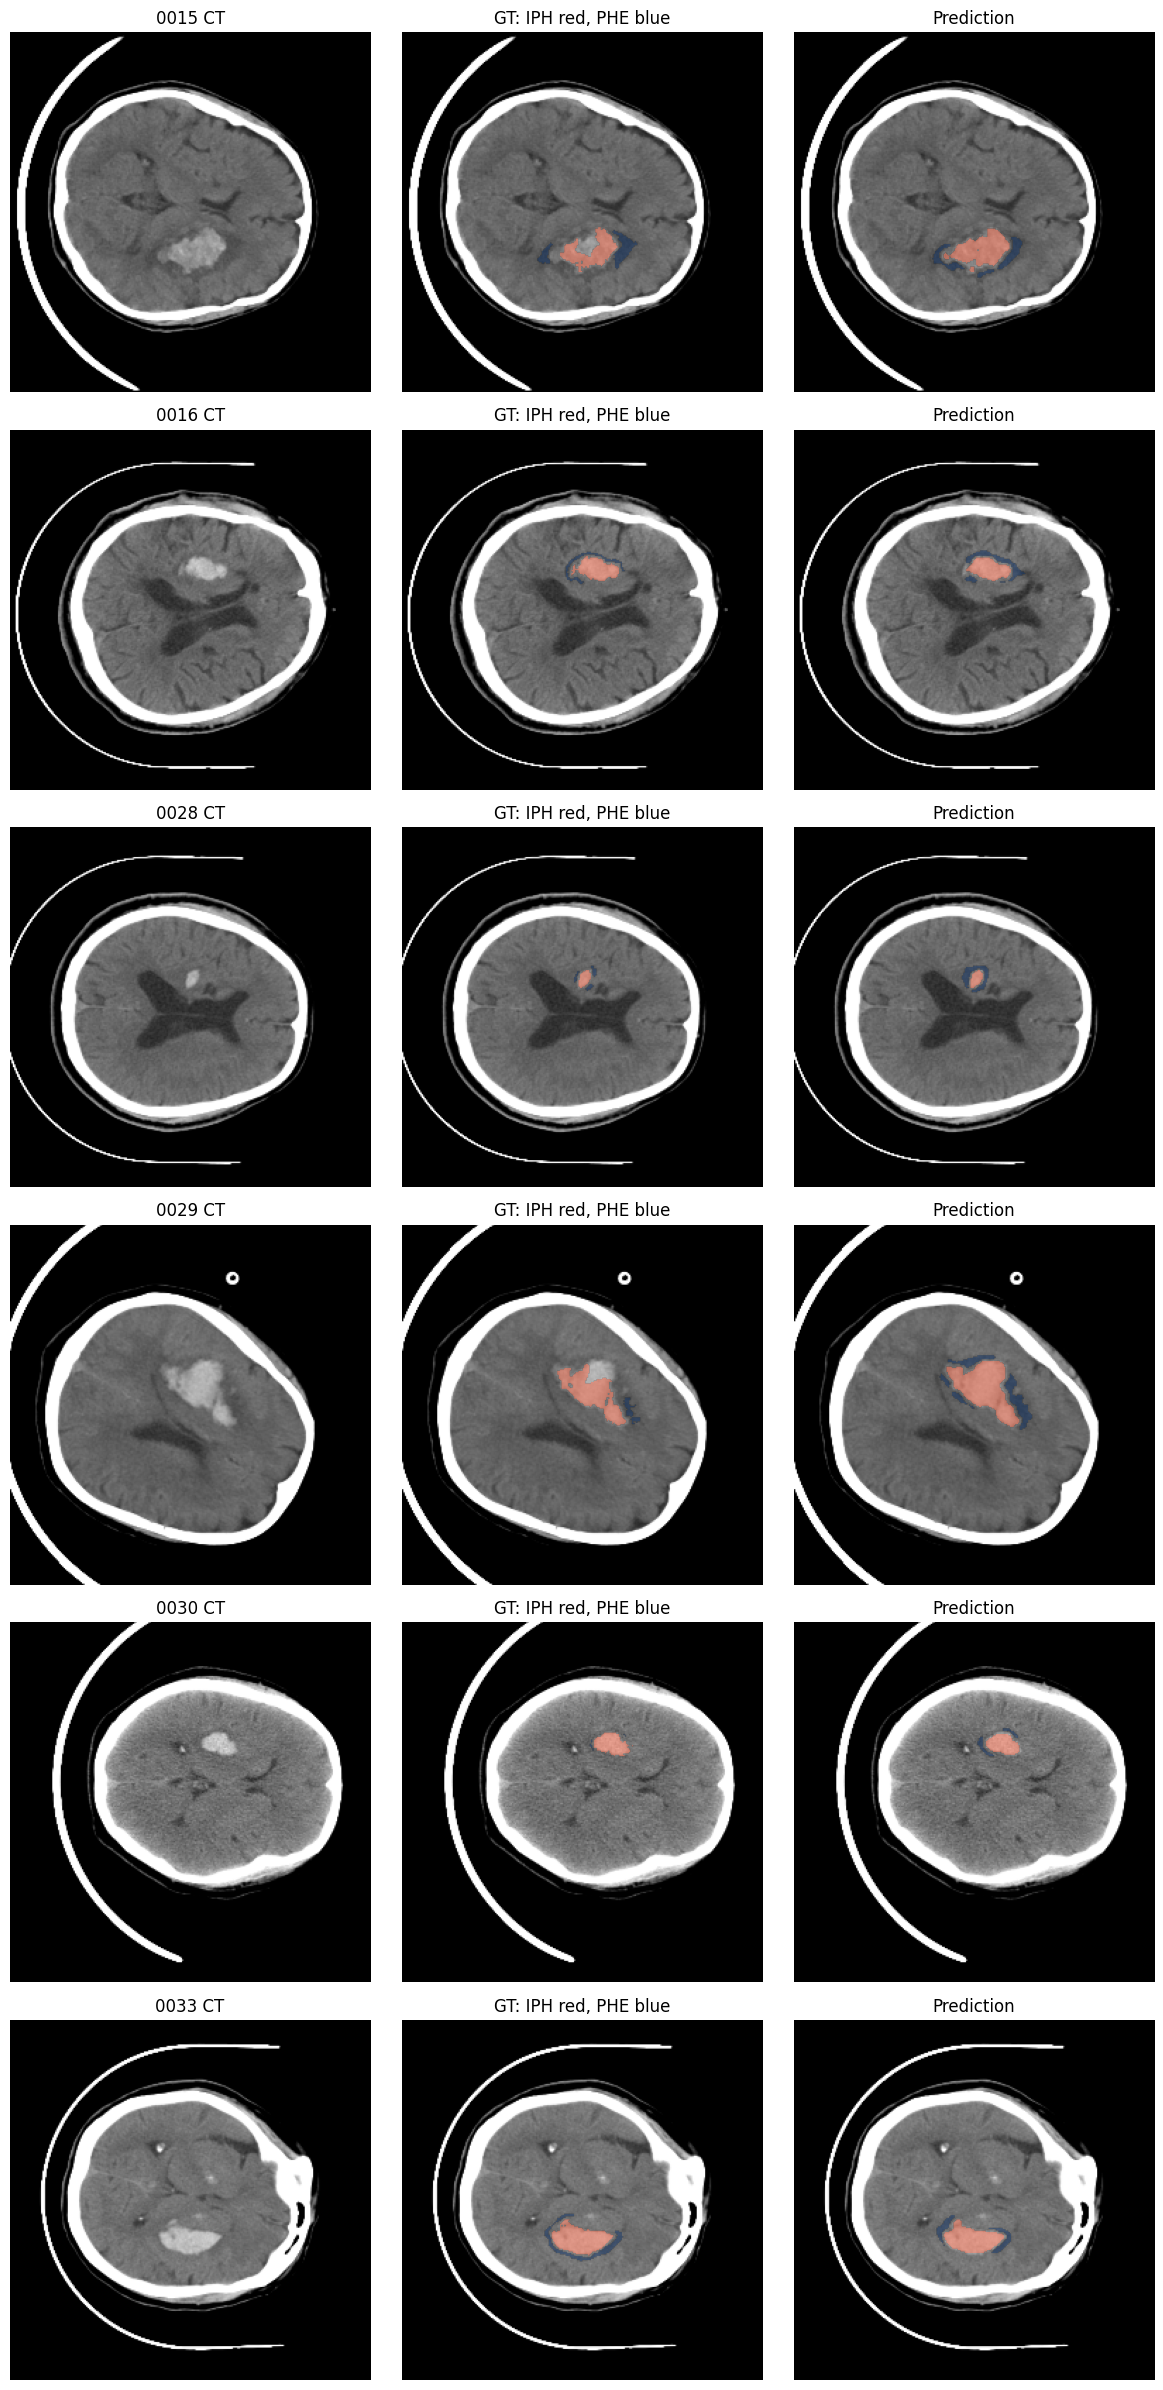

In [14]:
if TORCH_AVAILABLE and TORCHVISION_AVAILABLE and CFG.run_final_eval:
    if "eval_model" not in globals() or eval_model is None:
        eval_model, used_ckpt = load_best_model()
    if "tuned_threshold" not in globals():
        tuned_threshold = CFG.foreground_threshold

    if eval_model is not None:
        volume_parts = []
        slice_parts = []
        qualitative_cases = []

        for _, row in tqdm(test_rows.iterrows(), total=len(test_rows), desc="test volumes"):
            prob, spacing = predict_case_probabilities(eval_model, row)
            target, _, iph_source = load_target_for_row(row)
            pred = prob_to_label_volume(prob, tuned_threshold, spacing)

            if CFG.save_probability_npz:
                np.savez_compressed(PRED_DIR / f"{row['scan_id']}_prob_multiclass.npz", prob=prob.astype(np.float16), threshold=tuned_threshold)

            volume_parts.append(evaluate_volume_multiclass(row["scan_id"], pred, target, spacing, iph_source))

            s_all = evaluate_slice_multiclass(row["scan_id"], pred, target, spacing, positive_gt_only=False)
            s_pos = evaluate_slice_multiclass(row["scan_id"], pred, target, spacing, positive_gt_only=True)
            s_all["slice_set"] = "all_slices_empty_empty_nan"
            s_pos["slice_set"] = "positive_gt_only"
            slice_parts.extend([s_all, s_pos])

            if len(qualitative_cases) < 6:
                image, _, _ = load_nifti(Path(row["img_path"]))
                z = largest_label_slice(target)
                x_small = make_25d_multiwindow_stack(image, z, image_size=256)
                gt_small = resize_2d(target[:, :, z].astype(np.uint8), 256, order=0)
                pred_small = resize_2d(pred[:, :, z].astype(np.uint8), 256, order=0)
                qualitative_cases.append((row["scan_id"], x_small[len(CFG.slice_offsets) // 2, 0], gt_small, pred_small))

        volume_df = pd.concat(volume_parts, ignore_index=True)
        slice_df = pd.concat(slice_parts, ignore_index=True)
        volume_df.to_csv(TABLE_DIR / "3dff_test_volume_metrics.csv", index=False)
        slice_df.to_csv(TABLE_DIR / "3dff_test_slice_metrics.csv", index=False)

        main_volume_df = volume_df[volume_df["gt_positive"]].copy()
        volume_summary_main = summarize_metrics(
            main_volume_df,
            "3dff:test_volume_gt_positive",
            cols=["dsc", "jaccard", "precision", "recall", "hd95_mm", "hd_mm", "assd_mm", "nsd_1mm", "rvd", "rvd_signed", "volume_abs_error_ml"],
        )
        volume_summary_all = summarize_metrics(
            volume_df,
            "3dff:test_volume_all_cases_empty_empty_nan",
            cols=["dsc", "jaccard", "precision", "recall", "hd95_mm", "hd_mm", "assd_mm", "nsd_1mm", "rvd", "rvd_signed", "volume_abs_error_ml"],
        )

        extra_rows = []
        for class_name, part in volume_df.groupby("class_name"):
            pos = part[part["gt_positive"]]
            extra_rows.extend([
                {"group": "3dff:test_volume_gt_positive", "class_name": class_name, "metric": "volume_rmse_ml", "mean": float(np.sqrt(pos["volume_sq_error_ml2"].mean())) if len(pos) else np.nan, "std": np.nan, "median": np.nan, "n": len(pos), "n_inf": 0},
                {"group": "3dff:test_volume_gt_positive", "class_name": class_name, "metric": "volume_r2", "mean": r2_score_np(pos["target_volume_ml"], pos["pred_volume_ml"]) if len(pos) else np.nan, "std": np.nan, "median": np.nan, "n": len(pos), "n_inf": 0},
                {"group": "3dff:test_volume_all_cases_empty_empty_nan", "class_name": class_name, "metric": "case_detection_rate", "mean": pd.to_numeric(pos["detected"], errors="coerce").mean() if len(pos) else np.nan, "std": np.nan, "median": np.nan, "n": len(pos), "n_inf": 0},
                {"group": "3dff:test_volume_all_cases_empty_empty_nan", "class_name": class_name, "metric": "empty_case_fp_rate", "mean": pd.to_numeric(part.loc[~part["gt_positive"], "false_positive_case"], errors="coerce").mean(), "std": np.nan, "median": np.nan, "n": int((~part["gt_positive"]).sum()), "n_inf": 0},
            ])
        volume_summary = pd.concat([volume_summary_main, volume_summary_all, pd.DataFrame(extra_rows)], ignore_index=True)
        volume_summary.to_csv(TABLE_DIR / "3dff_test_volume_summary.csv", index=False)

        slice_summary = pd.concat([
            summarize_metrics(
                part,
                f"3dff:test_slice:{slice_set}",
                cols=["dice", "jaccard", "precision", "recall", "hd95_mm", "hd_mm"],
            )
            for slice_set, part in slice_df.groupby("slice_set")
        ], ignore_index=True)
        slice_summary.to_csv(TABLE_DIR / "3dff_test_slice_summary.csv", index=False)

        display(volume_summary)
        display(slice_summary)

        if len(qualitative_cases):
            fig, axes = plt.subplots(len(qualitative_cases), 3, figsize=(12, 4 * len(qualitative_cases)))
            if len(qualitative_cases) == 1:
                axes = np.expand_dims(axes, axis=0)
            for i, (scan_id, img, gt, pred) in enumerate(qualitative_cases):
                axes[i, 0].imshow(img, cmap="gray")
                axes[i, 0].set_title(f"{scan_id} CT")
                axes[i, 1].imshow(img, cmap="gray")
                axes[i, 1].imshow(np.ma.masked_where(gt != 1, gt), cmap="Reds", alpha=0.50, vmin=0, vmax=2)
                axes[i, 1].imshow(np.ma.masked_where(gt != 2, gt), cmap="Blues", alpha=0.45, vmin=0, vmax=2)
                axes[i, 1].set_title("GT: IPH red, PHE blue")
                axes[i, 2].imshow(img, cmap="gray")
                axes[i, 2].imshow(np.ma.masked_where(pred != 1, pred), cmap="Reds", alpha=0.50, vmin=0, vmax=2)
                axes[i, 2].imshow(np.ma.masked_where(pred != 2, pred), cmap="Blues", alpha=0.45, vmin=0, vmax=2)
                axes[i, 2].set_title("Prediction")
                for j in range(3):
                    axes[i, j].axis("off")
            plt.tight_layout()
            plt.savefig(FIG_DIR / "3dff_test_qualitative_cases.png", dpi=160, bbox_inches="tight")
            plt.show()
    else:
        print("No model checkpoint found.")
else:
    print("Final eval skipped.")


## 13. Paper reporting protocol


In [15]:
protocol = {
    "primary_task": "3D multi-class lesion segmentation on NCCT: background, IPH, PHE",
    "main_metric_table": str(TABLE_DIR / "3dff_test_volume_summary.csv"),
    "main_metrics": [
        "DSC / Dice, case-level 3D, gt-positive cases only",
        "Jaccard / IoU, case-level 3D, gt-positive cases only",
        "HD95 in mm, computed with NIfTI voxel spacing",
        "ASSD in mm, computed with NIfTI voxel spacing",
        "NSD at 1 mm tolerance",
        "precision, recall, RVD, volume absolute error in ml",
    ],
    "empty_case_policy": "Main lesion metrics exclude empty GT cases and store empty-empty as NaN; detection and empty-case FP rates are reported separately.",
    "iph_label_warning": "If CFG.true_iph_mask_dir is None, IPH metrics are against HU/PHE-derived pseudo labels, not manual IPH labels.",
    "do_not_mix": [
        "Do not compare positive-slice Dice with 3D volume Dice.",
        "Do not compare pseudo-IPH DSC with manual-IPH DSC without saying pseudo-label.",
        "Do not report all-case Dice if many empty cases are included unless empty handling is explicit.",
    ],
}

with open(LOG_DIR / "3dff_reporting_protocol.json", "w", encoding="utf-8") as f:
    json.dump(protocol, f, ensure_ascii=False, indent=2)

print(json.dumps(protocol, ensure_ascii=False, indent=2))


{
  "primary_task": "3D multi-class lesion segmentation on NCCT: background, IPH, PHE",
  "main_metric_table": "/kaggle/working/outputs_02_4_3dff_refined_pseudo_iph_phe_25d_segmentation/tables/3dff_test_volume_summary.csv",
  "main_metrics": [
    "DSC / Dice, case-level 3D, gt-positive cases only",
    "Jaccard / IoU, case-level 3D, gt-positive cases only",
    "HD95 in mm, computed with NIfTI voxel spacing",
    "ASSD in mm, computed with NIfTI voxel spacing",
    "NSD at 1 mm tolerance",
    "precision, recall, RVD, volume absolute error in ml"
  ],
  "empty_case_policy": "Main lesion metrics exclude empty GT cases and store empty-empty as NaN; detection and empty-case FP rates are reported separately.",
  "iph_label_warning": "If CFG.true_iph_mask_dir is None, IPH metrics are against HU/PHE-derived pseudo labels, not manual IPH labels.",
  "do_not_mix": [
    "Do not compare positive-slice Dice with 3D volume Dice.",
    "Do not compare pseudo-IPH DSC with manual-IPH DSC without sa